# Exploratory Data Analysis (EDA) - Crop Yield & Telemetry

**Project**: YieldSense AI: Crop Yield Prediction & Agricultural Productivity Forecasting System

**Objective**: Perform comprehensive Exploratory Data Analysis (EDA) on the crop yield dataset to understand feature distributions, identify anomalies, analyze correlation, and evaluate feature interactions. This serves as the data intelligence baseline for model development in Week 2.

## 1. Import Libraries
We import pandas, numpy, matplotlib, and seaborn for data processing and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting preferences
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset
We read the crop yield dataset downloaded from Explore-AI's repository mirror.

In [2]:
# Adjust paths relative to the notebooks/ directory
dataset_path = os.path.join('..', 'dataset', 'raw', 'kaggle_crop_yield', 'crop_yield.csv')
df = pd.read_csv(dataset_path)
print('Dataset successfully loaded!')

Dataset successfully loaded!


## 3. First Rows
Let's inspect the first 5 records of the dataset.

In [3]:
df.head()

,Region,Temperature,Rainfall,Soil_Type,Fertilizer_Usage,Pesticide_Usage,Irrigation,Crop_Variety,Yield
0,East,23.152156,803.362573,Clayey,204.792011,20.767590,1,Variety B,40.316318
1,West,19.382419,571.567670,Sandy,256.201737,49.290242,0,Variety A,26.846639
2,North,27.895890,-8.699637,Loamy,222.202626,25.316121,0,Variety C,-0.323558
3,East,26.741361,897.426194,Loamy,187.984090,17.115362,0,Variety C,45.440871
4,East,19.090286,649.384694,Loamy,110.459549,24.068804,1,Variety B,35.478118


## 4. Dataset Shape
Inspect dimensions of the data.

In [4]:
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')

Rows: 1000 | Columns: 9


## 5. Dataset Information
Check column data types and non-null counts.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Region            1000 non-null   object 
 1   Temperature       1000 non-null   float64
 2   Rainfall          1000 non-null   float64
 3   Soil_Type         1000 non-null   object 
 4   Fertilizer_Usage  1000 non-null   float64
 5   Pesticide_Usage   1000 non-null   float64
 6   Irrigation        1000 non-null   int64  
 7   Crop_Variety      1000 non-null   object 
 8   Yield             1000 non-null   float64
dtypes: float64(5), int64(1), object(3)
memory usage: 70.4+ KB


## 6. Descriptive Statistics
Evaluate numerical properties, means, std, and percentiles.

In [6]:
df.describe()

,Temperature,Rainfall,Fertilizer_Usage,Pesticide_Usage,Irrigation,Yield
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25.250082,498.018579,171.253446,30.014739,0.513000,26.263842
std,4.979438,199.537595,71.697830,11.478614,0.500081,10.181351
min,8.065931,-167.900036,50.519129,10.025101,0.000000,-8.426900
25%,21.823442,353.178888,109.618317,20.345079,0.000000,18.873992
50%,25.429272,494.189894,170.676081,30.340789,1.000000,26.324512
75%,28.687443,644.162691,232.056661,39.393116,1.000000,33.537327
max,42.479389,1084.150513,299.762375,49.993970,1.000000,54.415047


## 7. Missing Value Analysis
Check if there are null values that need imputation.

In [7]:
df.isnull().sum()

Region              0
Temperature         0
Rainfall            0
Soil_Type           0
Fertilizer_Usage    0
Pesticide_Usage     0
Irrigation          0
Crop_Variety        0
Yield               0
dtype: int64

## 8. Duplicate Analysis
Check for duplicate observations.

In [8]:
print(f'Number of duplicates: {df.duplicated().sum()}')

Number of duplicates: 0


## 9. Data Type Analysis
Separate numerical and categorical variables.

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Numerical Columns: {num_cols}')
print(f'Categorical Columns: {cat_cols}')

Numerical Columns: ['Temperature', 'Rainfall', 'Fertilizer_Usage', 'Pesticide_Usage', 'Irrigation', 'Yield']
Categorical Columns: ['Region', 'Soil_Type', 'Crop_Variety']


## 10. Numerical Feature Distributions
Plot histograms to visualize features distribution.

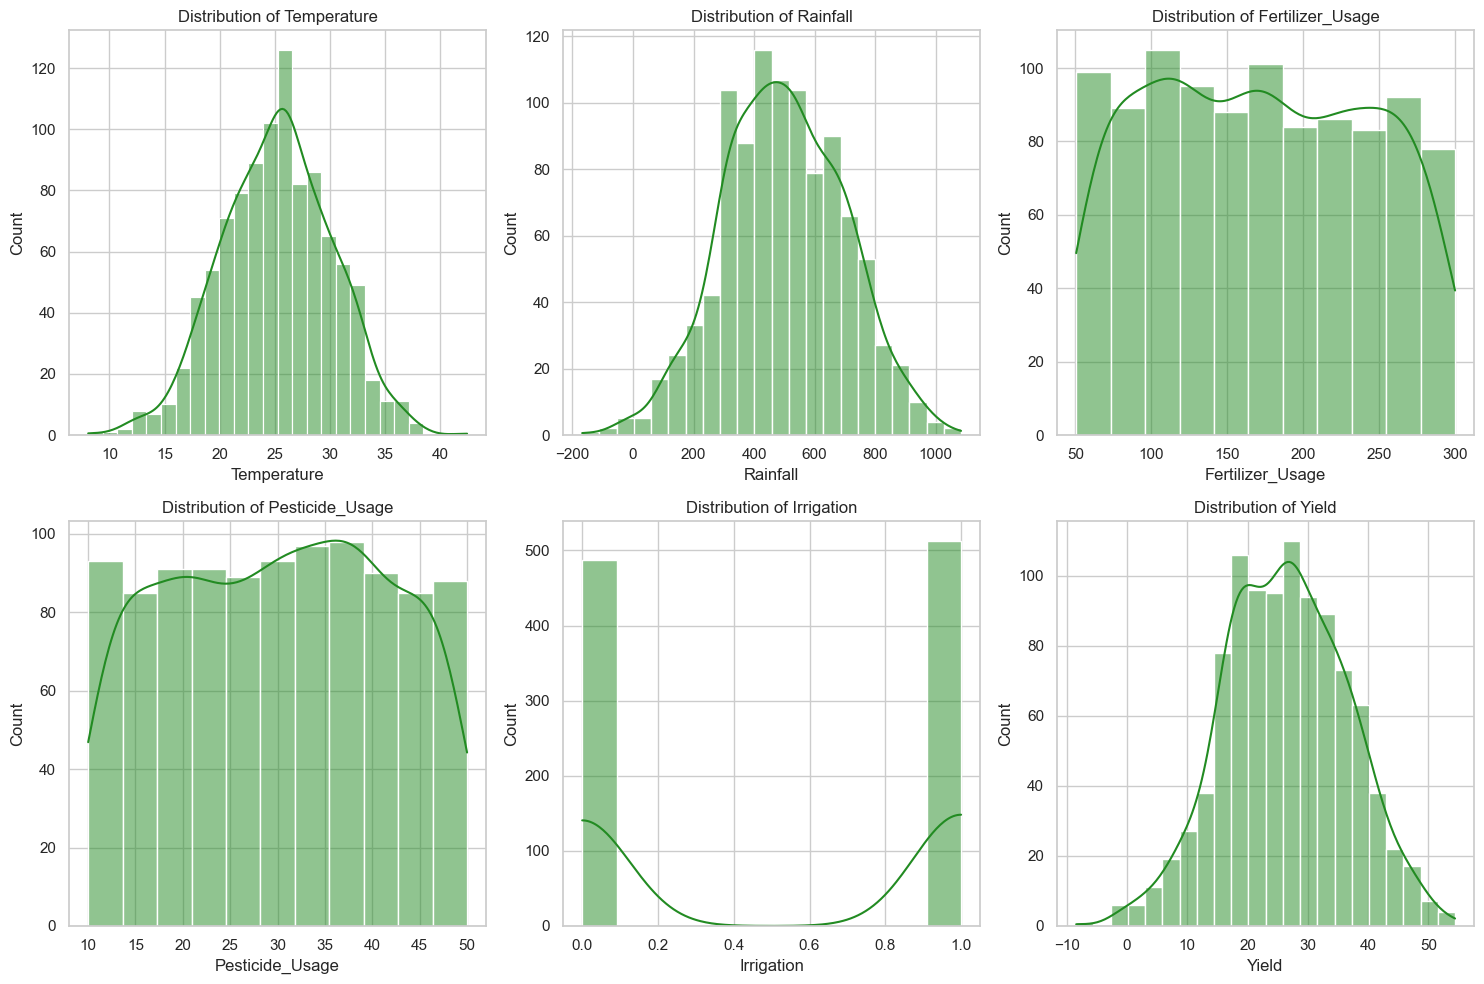

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='forestgreen')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## 11. Categorical Feature Distributions
Check values count for categorical variables.

C:\Users\sirib\AppData\Local\Temp\ipykernel_692\2231144815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
C:\Users\sirib\AppData\Local\Temp\ipykernel_692\2231144815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
C:\Users\sirib\AppData\Local\Temp\ipykernel_692\2231144815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')


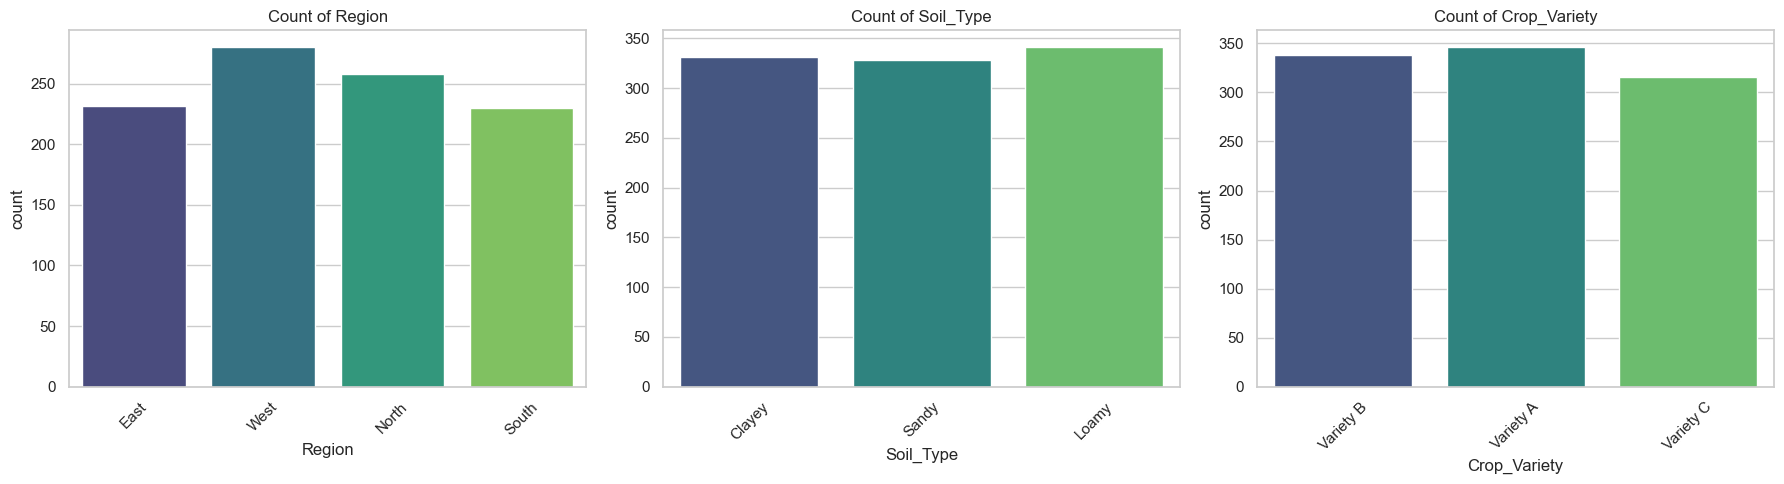

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 12. Target (Yield) Distribution
Analyze the target variable to see if there is skewness.

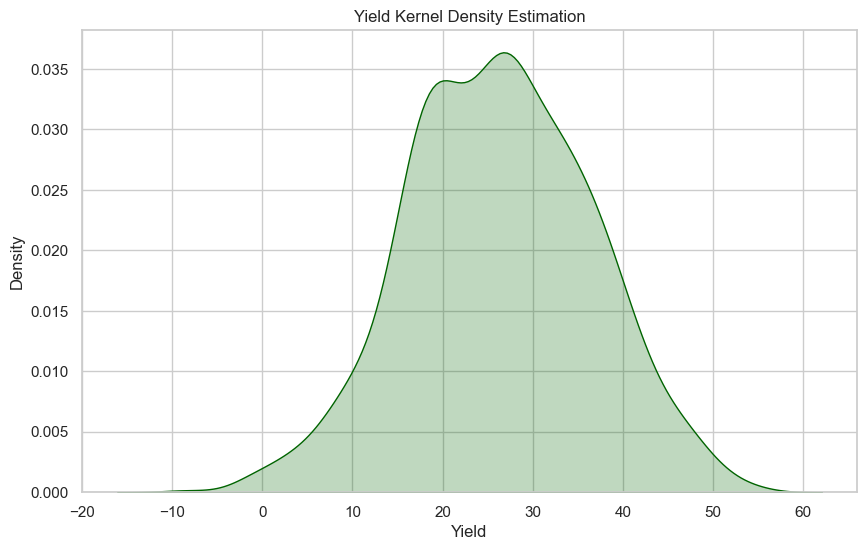

In [12]:
sns.kdeplot(df['Yield'], fill=True, color='darkgreen')
plt.title('Yield Kernel Density Estimation')
plt.show()

## 13. Outlier and Anomaly Analysis
We look for statistical outliers and non-physical values (like negative values for attributes that must be positive).

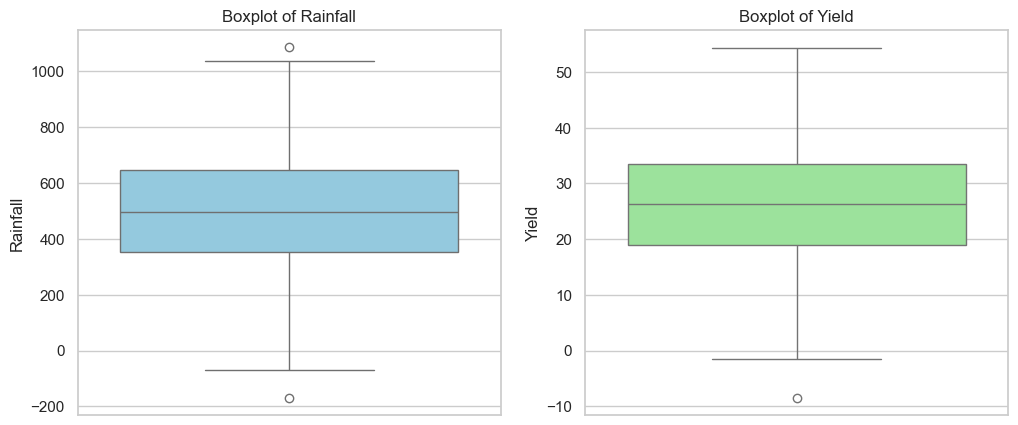

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y='Rainfall', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Rainfall')

sns.boxplot(y='Yield', data=df, ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Yield')

plt.show()

In [14]:
# Identify anomalous rows
negative_rainfall = df[df['Rainfall'] < 0]
negative_yield = df[df['Yield'] < 0]
print(f'Rows with negative Rainfall: {len(negative_rainfall)}')
print(f'Rows with negative Yield: {len(negative_yield)}')
if len(negative_rainfall) > 0:
    print('\nSample negative rainfall records:')
    print(negative_rainfall.head(3))

Rows with negative Rainfall: 7
Rows with negative Yield: 7

Sample negative rainfall records:
   Region  Temperature   Rainfall Soil_Type  Fertilizer_Usage  \
2   North    27.895890  -8.699637     Loamy        222.202626   
13   East    27.961760 -25.357251    Clayey        228.166405   
24   West    29.044928 -14.776423     Loamy        263.413637   

    Pesticide_Usage  Irrigation Crop_Variety     Yield  
2         25.316121           0    Variety C -0.323558  
13        38.045769           1    Variety C -0.476734  
24        33.765456           1    Variety B -1.469783  


## 14. Correlation Analysis
Compute pairwise correlation for numerical features.

In [15]:
df[num_cols].corr()

,Temperature,Rainfall,Fertilizer_Usage,Pesticide_Usage,Irrigation,Yield
Temperature,1.000000,0.003071,-0.029462,0.038465,-0.025574,0.057396
Rainfall,0.003071,1.000000,-0.022499,-0.043367,0.025840,0.986698
Fertilizer_Usage,-0.029462,-0.022499,1.000000,-0.047222,-0.050501,-0.166688
Pesticide_Usage,0.038465,-0.043367,-0.047222,1.000000,0.030822,-0.033239
Irrigation,-0.025574,0.025840,-0.050501,0.030822,1.000000,0.056532
Yield,0.057396,0.986698,-0.166688,-0.033239,0.056532,1.000000


## 15. Correlation Heatmap
Plot a heatmap to identify multi-collinearity and feature-to-target relationships.

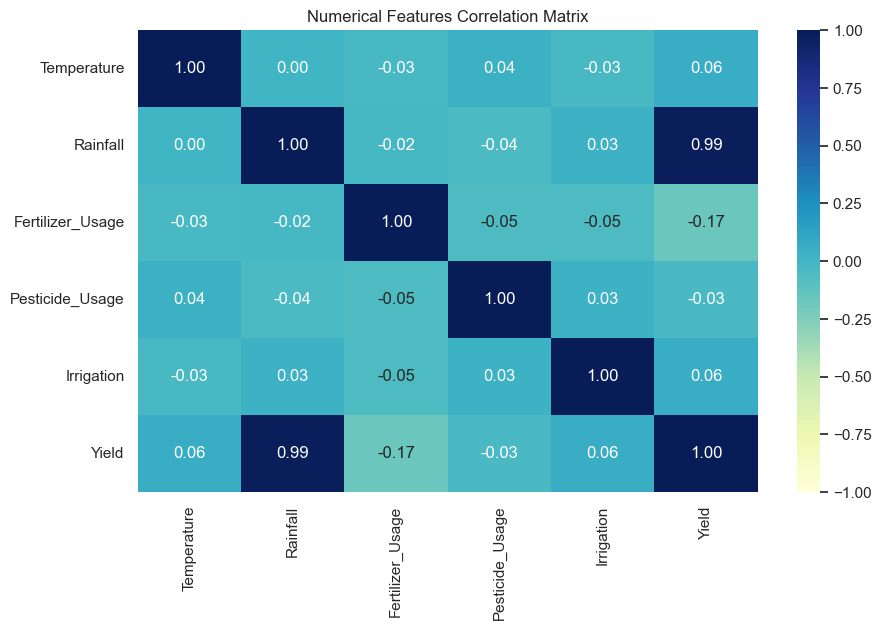

In [16]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Numerical Features Correlation Matrix')
plt.show()

## 16. Yield Distribution by Region and Soil Type
Check target values partitioned by categorical parameters.

C:\Users\sirib\AppData\Local\Temp\ipykernel_692\1479610630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Yield', data=df, ax=axes[0], palette='Set2')
C:\Users\sirib\AppData\Local\Temp\ipykernel_692\1479610630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Soil_Type', y='Yield', data=df, ax=axes[1], palette='Set3')


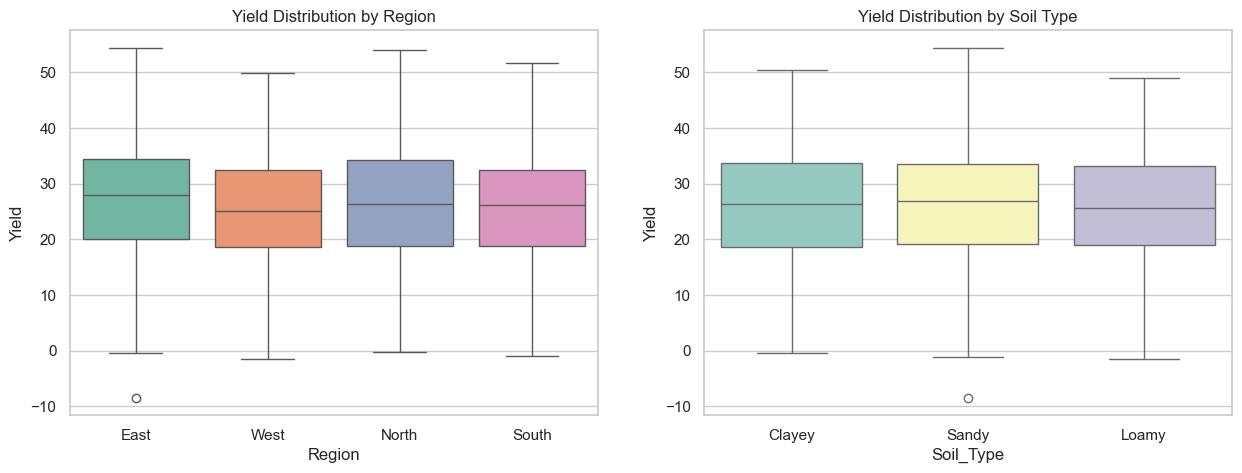

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Region', y='Yield', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Yield Distribution by Region')

sns.boxplot(x='Soil_Type', y='Yield', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Yield Distribution by Soil Type')
plt.show()

## 17. Feature vs Yield Scatter Plots
Evaluate numerical variables relation against the target Yield.

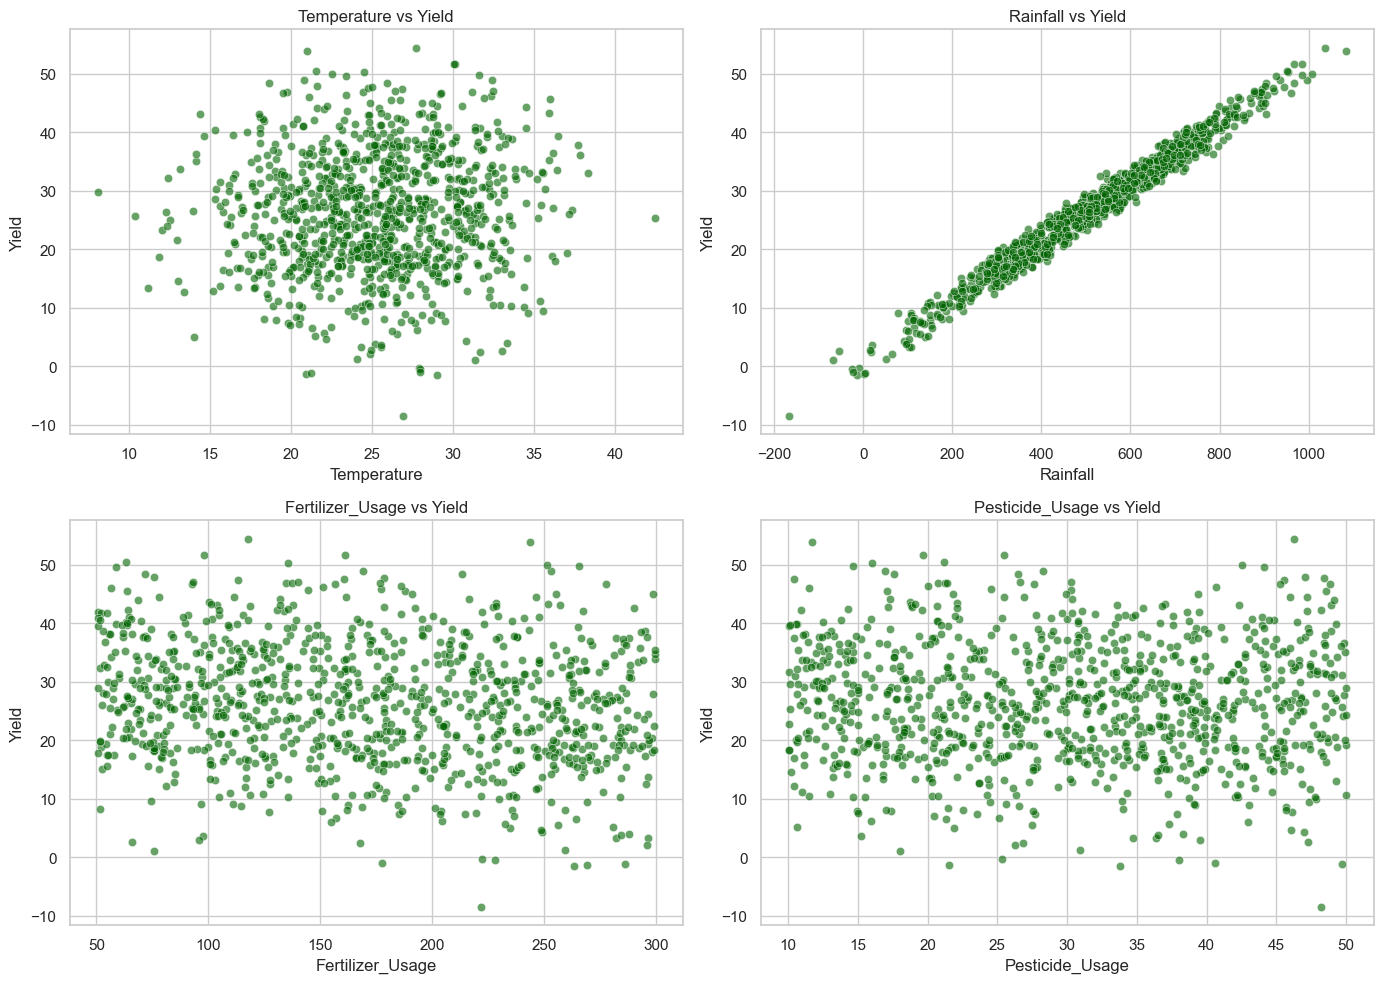

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features_to_plot = ['Temperature', 'Rainfall', 'Fertilizer_Usage', 'Pesticide_Usage']
for i, col in enumerate(features_to_plot):
    sns.scatterplot(x=col, y='Yield', data=df, alpha=0.6, color='darkgreen', ax=axes[i])
    axes[i].set_title(f'{col} vs Yield')

plt.tight_layout()
plt.show()

## 18. Important Observations
1. **Rainfall Anomaly**: There are multiple records where `Rainfall` is negative (min value of around -9.0). Since rainfall cannot be negative, this is a data collection error or missing value indicator.
2. **Yield Anomaly**: Similarly, `Yield` has negative outlier values (min of around -0.3). These must be corrected as negative yields are physically impossible.
3. **Data Completeness**: No missing values (`NaN`) were found, but the negative numbers function as semantic null values.
4. **Correlations**: `Fertilizer_Usage` and `Pesticide_Usage` show a positive relationship with `Yield`. `Rainfall` and `Temperature` show mild relationships but need cleaning to reflect the true interaction.

## 19. EDA Conclusions
- The dataset forms a robust basis for crop yield forecasting.
- The features are continuous weather and input variables combined with discrete regions/soil classifications.
- Standard regression/tree-based algorithms will benefit from cleaning features anomalies first.

## 20. Recommended Preprocessing Steps (Milestone 2 Prep)
1. **Clamping**: Set negative `Rainfall` and negative `Yield` values to a minimum threshold of `0.0` or replace them with column means.
2. **One-Hot Encoding**: Convert categorical variables (`Region`, `Soil_Type`, `Crop_Variety`) into binary dummy columns.
3. **Scaling**: Standardize continuous features (`Temperature`, `Rainfall`, `Fertilizer_Usage`, `Pesticide_Usage`) using Standard or MinMax scaling for algorithms like neural networks.